In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
from scipy import stats

plot_path = '/home/u/u241308/figures/'

In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
time_min1 = 1965
time_max1 = 1995

In [4]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

#central europe
lon_min_ce = 5
lon_max_ce = 30#10
lat_min_ce = 48
lat_max_ce = 65#58

#select North America area
lon_min_nam = -77
lon_max_nam = -57
lat_min_nam = 47
lat_max_nam = 61

#select Greenland area
lon_min_gl = -55
lon_max_gl = -35
lat_min_gl = 60
lat_max_gl = 75

# Select lead years

In [5]:
lead_year = 1

In [6]:
#1-13 for Dec-Nov first lead year, 13-25 for Dec-Nov second lead year
if lead_year == 1:
    lead_min = 1 #to start in December, first lead year
    lead_max = 13 #To end in November, first lead year
if lead_year == 2:
    lead_min = 13 #to start in December, first lead year
    lead_max = 25 #To end in November, first lead year

# Hybrid-ML

In [7]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min1,time_max1):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_ML_NA/anomaly/'
    file = 'sst_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_ML:
        sst_ML = sst_ML.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_ML)

#concatenate along time dimension
sst_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_ML['lon'] = np.where(sst_ML.lon > 180,sst_ML.lon-360,sst_ML.lon)
ind_sort = np.argsort(sst_ML.lon)
sst_ML = sst_ML[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_ML = sst_ML.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_ML = sst_ML.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
sst_ML = sst_ML.mean(dim='sfc')

#select SPG area
lon_sel = (sst_ML.lon>=lon_min_spg)&(sst_ML.lon<=lon_max_spg)
lat_sel = (sst_ML.lat>=lat_min_spg)&(sst_ML.lat<=lat_max_spg)
sst_ML_spg_t1 = sst_ML[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
sst_ML_spg_t1['time'] = pd.to_datetime(sst_ML_spg_t1['time']) - pd.offsets.MonthBegin()
sst_ML_spg_t1['time'] = sst_ML_spg_t1['time'].dt.floor('D')

In [8]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min1,time_max1):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_ML_NA/anomaly/'
    file = 'tas_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_ML:
        tas_ML = tas_ML.tas.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(tas_ML)

#concatenate along time dimension
tas_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
tas_ML['lon'] = np.where(tas_ML.lon > 180,tas_ML.lon-360,tas_ML.lon)
ind_sort = np.argsort(tas_ML.lon)
tas_ML = tas_ML[:,:,:,ind_sort.values]

#give different coordinates for each ensemble member in sfc:
tas_ML = tas_ML.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
tas_ML = tas_ML.mean(dim='sfc')

#homogenize time dimension, so each month's time corresponds to the first day, and first our
tas_ML['time'] = pd.to_datetime(tas_ML['time']) - pd.offsets.MonthBegin()
tas_ML['time'] = tas_ML['time'].dt.floor('D')

#select ce area
lon_sel = (tas_ML.lon>=lon_min_ce)&(tas_ML.lon<=lon_max_ce)
lat_sel = (tas_ML.lat>=lat_min_ce)&(tas_ML.lat<=lat_max_ce)
tas_ML_ce_t1 = tas_ML[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select North America area
lon_sel = (tas_ML.lon>=lon_min_nam)&(tas_ML.lon<=lon_max_nam)
lat_sel = (tas_ML.lat>=lat_min_nam)&(tas_ML.lat<=lat_max_nam)
tas_ML_nam_t1 = tas_ML[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select Greenland area
lon_sel = (tas_ML.lon>=lon_min_gl)&(tas_ML.lon<=lon_max_gl)
lat_sel = (tas_ML.lat>=lat_min_gl)&(tas_ML.lat<=lat_max_gl)
tas_ML_gl_t1 = tas_ML[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

# Standard

In [9]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min1,time_max1):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_benchmark/anomaly/'
    file = 'sst_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_MPI:
        sst_MPI = sst_MPI.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_MPI)

#concatenate along time dimension
sst_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_MPI['lon'] = np.where(sst_MPI.lon > 180,sst_MPI.lon-360,sst_MPI.lon)
ind_sort = np.argsort(sst_MPI.lon)
sst_MPI = sst_MPI[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_MPI = sst_MPI.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_MPI = sst_MPI.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
sst_MPI = sst_MPI.mean(dim='sfc')

#select SPG area
lon_sel = (sst_MPI.lon>=lon_min_spg)&(sst_MPI.lon<=lon_max_spg)
lat_sel = (sst_MPI.lat>=lat_min_spg)&(sst_MPI.lat<=lat_max_spg)
sst_MPI_spg_t1 = sst_MPI[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
sst_MPI_spg_t1['time'] = sst_MPI_spg_t1['time'].dt.floor('D')

In [10]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min1,time_max1):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_benchmark/anomaly/'
    file = 'tas_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_MPI:
        tas_MPI = tas_MPI.tas.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(tas_MPI)

#concatenate along time dimension
tas_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
tas_MPI['lon'] = np.where(tas_MPI.lon > 180,tas_MPI.lon-360,tas_MPI.lon)
ind_sort = np.argsort(tas_MPI.lon)
tas_MPI = tas_MPI[:,:,:,ind_sort.values]

#give different coordinates for each ensemble member in sfc:
tas_MPI = tas_MPI.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
tas_MPI = tas_MPI.mean(dim='sfc')

#homogenize time dimension, so each month's time corresponds to the first day, and first our
tas_MPI['time'] = tas_MPI['time'].dt.floor('D')

#select ce area
lon_sel = (tas_MPI.lon>=lon_min_ce)&(tas_MPI.lon<=lon_max_ce)
lat_sel = (tas_MPI.lat>=lat_min_ce)&(tas_MPI.lat<=lat_max_ce)
tas_MPI_ce_t1 = tas_MPI[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select North America area
lon_sel = (tas_MPI.lon>=lon_min_nam)&(tas_MPI.lon<=lon_max_nam)
lat_sel = (tas_MPI.lat>=lat_min_nam)&(tas_MPI.lat<=lat_max_nam)
tas_MPI_nam_t1 = tas_MPI[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select Greenland area
lon_sel = (tas_MPI.lon>=lon_min_gl)&(tas_MPI.lon<=lon_max_gl)
lat_sel = (tas_MPI.lat>=lat_min_gl)&(tas_MPI.lat<=lat_max_gl)
tas_MPI_gl_t1 = tas_MPI[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

# ERA5

In [11]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_sst_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
sst_era = xr.open_dataset(path+file).sst

#new longitudes
sst_era['lon'] = np.where(sst_era.lon > 180,sst_era.lon-360,sst_era.lon)
ind_sort = np.argsort(sst_era.lon)
sst_era = sst_era[:,:,ind_sort.values]

#select SPG area
lon_sel = (sst_era.lon>=lon_min_spg)&(sst_era.lon<=lon_max_spg)
lat_sel = (sst_era.lat>=lat_min_spg)&(sst_era.lat<=lat_max_spg)
sst_era_spg = sst_era[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#homogenize to MPI and ML
sst_era_spg_t1 = sst_era_spg.sel(time=slice(sst_MPI_spg_t1.time[0].time, sst_MPI_spg_t1.time[-1].time))

In [12]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_tas_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
tas_era = xr.open_dataset(path+file).t2m[:,0] #remove exp variable

#new longitudes
tas_era['lon'] = np.where(tas_era.lon > 180,tas_era.lon-360,tas_era.lon)
ind_sort = np.argsort(tas_era.lon)
tas_era = tas_era[:,:,ind_sort.values]

#select ce area
lon_sel = (tas_era.lon>=lon_min_ce)&(tas_era.lon<=lon_max_ce)
lat_sel = (tas_era.lat>=lat_min_ce)&(tas_era.lat<=lat_max_ce)
tas_era_ce = tas_era[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select nam area
lon_sel = (tas_era.lon>=lon_min_nam)&(tas_era.lon<=lon_max_nam)
lat_sel = (tas_era.lat>=lat_min_nam)&(tas_era.lat<=lat_max_nam)
tas_era_nam = tas_era[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#select gl area
lon_sel = (tas_era.lon>=lon_min_gl)&(tas_era.lon<=lon_max_gl)
lat_sel = (tas_era.lat>=lat_min_gl)&(tas_era.lat<=lat_max_gl)
tas_era_gl = tas_era[:,lat_sel,lon_sel].mean(dim=('lat','lon'))

#homogenize to MPI and ML
tas_era_ce_t1 = tas_era_ce.sel(time=slice(tas_MPI_ce_t1.time[0].time, tas_MPI_ce_t1.time[-1].time))
tas_era_nam_t1 = tas_era_nam.sel(time=slice(tas_MPI_nam_t1.time[0].time, tas_MPI_nam_t1.time[-1].time))
tas_era_gl_t1 = tas_era_gl.sel(time=slice(tas_MPI_gl_t1.time[0].time, tas_MPI_gl_t1.time[-1].time))


# Seasonal correlation

In [13]:
def compute_seasonal_means(da):
    time = da['time'].to_index()

    season_year = time.year + (time.month == 12)
    season = da['time'].dt.season.values

    season_id = [f"{y}-{s}" for y, s in zip(season_year, season)]

    da = da.assign_coords(
        season=('time', season),
        season_year=('time', season_year),
        season_id=('time', season_id)
    )

    grouped = da.groupby('season_id').mean('time')

    season_ts = {}
    for sid in grouped['season_id'].values:
        year, s = sid.split('-')
        year = int(year)
        if s not in season_ts:
            season_ts[s] = []
        da_season = grouped.sel(season_id=sid).expand_dims({'season_year': [year]})
        season_ts[s].append(da_season)

    for season in season_ts:
        season_ts[season] = xr.concat(season_ts[season], dim='season_year')

    return season_ts

In [14]:
# Compute seasonal mean
spg_era_t1_seasonal = compute_seasonal_means(sst_era_spg_t1)
spg_MPI_t1_seasonal = compute_seasonal_means(sst_MPI_spg_t1)
spg_ML_t1_seasonal = compute_seasonal_means(sst_ML_spg_t1)

ce_era_t1_seasonal = compute_seasonal_means(tas_era_ce_t1)
ce_MPI_t1_seasonal = compute_seasonal_means(tas_MPI_ce_t1)
ce_ML_t1_seasonal = compute_seasonal_means(tas_ML_ce_t1)

nam_era_t1_seasonal = compute_seasonal_means(tas_era_nam_t1)
nam_MPI_t1_seasonal = compute_seasonal_means(tas_MPI_nam_t1)
nam_ML_t1_seasonal = compute_seasonal_means(tas_ML_nam_t1)

gl_era_t1_seasonal = compute_seasonal_means(tas_era_gl_t1)
gl_MPI_t1_seasonal = compute_seasonal_means(tas_MPI_gl_t1)
gl_ML_t1_seasonal = compute_seasonal_means(tas_ML_gl_t1)

In [15]:
#Compute seasonal correlation
season_list = ['DJF','MAM','JJA','SON']

spg_skill_MPI_seasonal_t1_correlation = {}
spg_skill_ML_seasonal_t1_correlation = {}
ce_skill_MPI_seasonal_t1_correlation = {}
ce_skill_ML_seasonal_t1_correlation = {}
nam_skill_MPI_seasonal_t1_correlation = {}
nam_skill_ML_seasonal_t1_correlation = {}
gl_skill_MPI_seasonal_t1_correlation = {}
gl_skill_ML_seasonal_t1_correlation = {}
for seas in season_list:
    #SPG time 1
    x_corr = spg_era_t1_seasonal[seas]
    y_corr = spg_MPI_t1_seasonal[seas]
    spg_skill_MPI_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)
    
    y_corr = spg_ML_t1_seasonal[seas]
    spg_skill_ML_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)

    #ce time1
    x_corr = ce_era_t1_seasonal[seas]
    y_corr = ce_MPI_t1_seasonal[seas]
    ce_skill_MPI_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)
    
    y_corr = ce_ML_t1_seasonal[seas]
    ce_skill_ML_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)

    #nam time1
    x_corr = nam_era_t1_seasonal[seas]
    y_corr = nam_MPI_t1_seasonal[seas]
    nam_skill_MPI_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)
    
    y_corr = nam_ML_t1_seasonal[seas]
    nam_skill_ML_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)

    #gl time1
    x_corr = gl_era_t1_seasonal[seas]
    y_corr = gl_MPI_t1_seasonal[seas]
    gl_skill_MPI_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)
    
    y_corr = gl_ML_t1_seasonal[seas]
    gl_skill_ML_seasonal_t1_correlation[seas] = stats.pearsonr(x_corr,y_corr)

# Plot

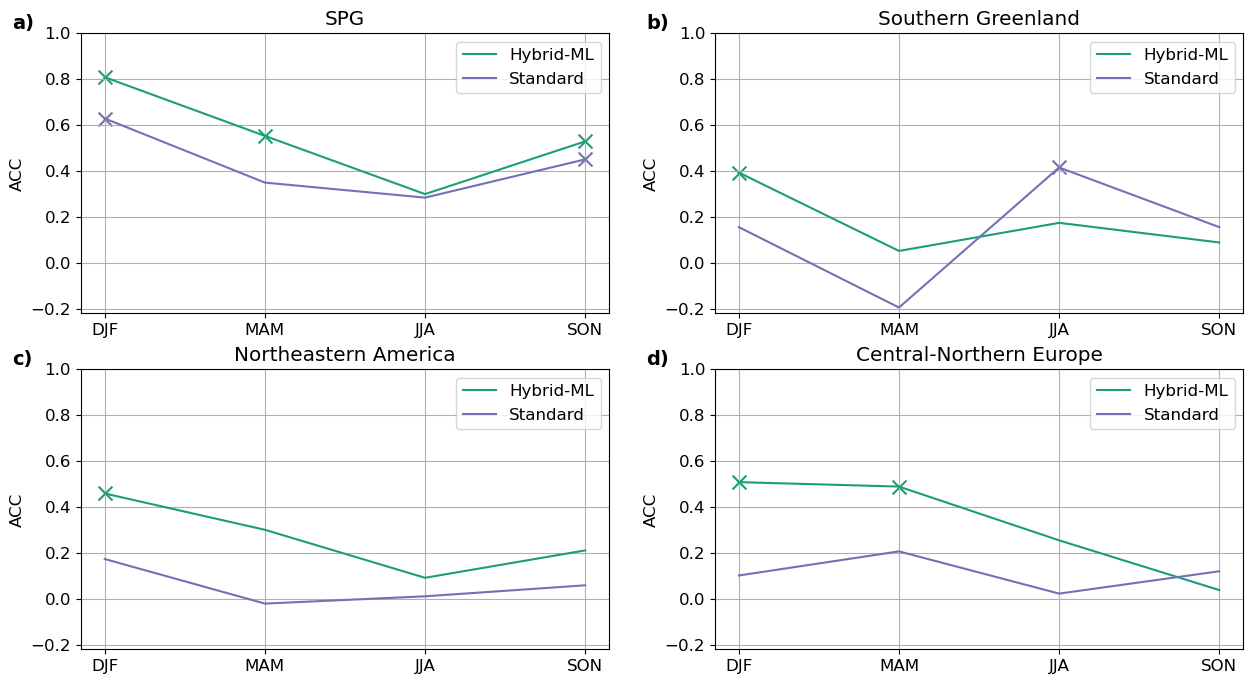

In [16]:
spg_MPI_t1_plot = []
spg_ML_t1_plot = []
ce_MPI_t1_plot = []
ce_ML_t1_plot = []
nam_MPI_t1_plot = []
nam_ML_t1_plot = []
gl_MPI_t1_plot = []
gl_ML_t1_plot = []

spg_MPI_t1_sig = []
spg_ML_t1_sig = []
ce_MPI_t1_sig = []
ce_ML_t1_sig = []
nam_MPI_t1_sig = []
nam_ML_t1_sig = []
gl_MPI_t1_sig = []
gl_ML_t1_sig = []
for idx,seas in enumerate(season_list):
    spg_MPI_t1_plot.append(spg_skill_MPI_seasonal_t1_correlation[seas][0])
    spg_ML_t1_plot.append(spg_skill_ML_seasonal_t1_correlation[seas][0])
    ce_MPI_t1_plot.append(ce_skill_MPI_seasonal_t1_correlation[seas][0])
    ce_ML_t1_plot.append(ce_skill_ML_seasonal_t1_correlation[seas][0])
    nam_MPI_t1_plot.append(nam_skill_MPI_seasonal_t1_correlation[seas][0])
    nam_ML_t1_plot.append(nam_skill_ML_seasonal_t1_correlation[seas][0])
    gl_MPI_t1_plot.append(gl_skill_MPI_seasonal_t1_correlation[seas][0])
    gl_ML_t1_plot.append(gl_skill_ML_seasonal_t1_correlation[seas][0])

    spg_MPI_t1_sig.append(spg_skill_MPI_seasonal_t1_correlation[seas][1])
    spg_ML_t1_sig.append(spg_skill_ML_seasonal_t1_correlation[seas][1])
    ce_MPI_t1_sig.append(ce_skill_MPI_seasonal_t1_correlation[seas][1])
    ce_ML_t1_sig.append(ce_skill_ML_seasonal_t1_correlation[seas][1])
    nam_MPI_t1_sig.append(nam_skill_MPI_seasonal_t1_correlation[seas][1])
    nam_ML_t1_sig.append(nam_skill_ML_seasonal_t1_correlation[seas][1])
    gl_MPI_t1_sig.append(gl_skill_MPI_seasonal_t1_correlation[seas][1])
    gl_ML_t1_sig.append(gl_skill_ML_seasonal_t1_correlation[seas][1])

row = 2#4
column = 2
if lead_year == 1:
    y_lim_min = -0.22
    y_lim_max = 1
if lead_year == 2:
    y_lim_min = -0.3
    y_lim_max = 1

fig = plt.figure(figsize=(15,8))#(22,15))
plt.rcParams.update({'font.size': 12})

MPI_color = '#7570b3'
ML_color = '#1b9e77'

#================== SPG =========================
ax1 = plt.subplot(row,column,1)
plt.plot(spg_ML_t1_plot,ML_color,label='Hybrid-ML')
plt.plot(spg_MPI_t1_plot,MPI_color,label='Standard')
plt.xticks(np.arange(4),labels=season_list)
plt.ylabel('ACC')
plt.grid()
plt.legend()
plt.title('SPG')
plt.ylim([y_lim_min,y_lim_max])

# add X on significant skill
sig_ML = np.array(spg_ML_t1_sig) < 0.05
sig_MPI = np.array(spg_MPI_t1_sig) < 0.05
ax1.scatter(np.arange(len(season_list))[sig_MPI],
            np.array(spg_MPI_t1_plot)[sig_MPI],
            marker='x', color=MPI_color, s=100, label='_nolegend_')

ax1.scatter(np.arange(len(season_list))[sig_ML],
            np.array(spg_ML_t1_plot)[sig_ML],
            marker='x', color=ML_color, s=100, label='_nolegend_')

#================== Central Northern Europe =========================
ax2 = plt.subplot(row,column,4)
plt.plot(ce_ML_t1_plot,ML_color,label='Hybrid-ML')
plt.plot(ce_MPI_t1_plot,MPI_color,label='Standard')
plt.xticks(np.arange(4),labels=season_list)
plt.ylabel('ACC')
plt.grid()
plt.legend()
plt.title('Central-Northern Europe')
plt.ylim([y_lim_min,y_lim_max])

# add X on significant skill
sig_ML = np.array(ce_ML_t1_sig) < 0.05
sig_MPI = np.array(ce_MPI_t1_sig) < 0.05
ax2.scatter(np.arange(len(season_list))[sig_MPI],
            np.array(ce_MPI_t1_plot)[sig_MPI],
            marker='x', color=MPI_color, s=100, label='_nolegend_')

ax2.scatter(np.arange(len(season_list))[sig_ML],
            np.array(ce_ML_t1_plot)[sig_ML],
            marker='x', color=ML_color, s=100, label='_nolegend_')

#================== Northwestern America =========================
ax3 = plt.subplot(row,column,3)
plt.plot(nam_ML_t1_plot,ML_color,label='Hybrid-ML')
plt.plot(nam_MPI_t1_plot,MPI_color,label='Standard')
plt.xticks(np.arange(4),labels=season_list)
plt.ylabel('ACC')
plt.grid()
plt.legend()
plt.title('Northeastern America')
plt.ylim([y_lim_min,y_lim_max])

# add X on significant skill
sig_ML = np.array(nam_ML_t1_sig) < 0.05
sig_MPI = np.array(nam_MPI_t1_sig) < 0.05
ax3.scatter(np.arange(len(season_list))[sig_MPI],
            np.array(nam_MPI_t1_plot)[sig_MPI],
            marker='x', color=MPI_color, s=100, label='_nolegend_')

ax3.scatter(np.arange(len(season_list))[sig_ML],
            np.array(nam_ML_t1_plot)[sig_ML],
            marker='x', color=ML_color, s=100, label='_nolegend_')

#================== Southern Greenland =========================
ax4 = plt.subplot(row,column,2)
plt.plot(gl_ML_t1_plot,ML_color,label='Hybrid-ML')
plt.plot(gl_MPI_t1_plot,MPI_color,label='Standard')
plt.xticks(np.arange(4),labels=season_list)
plt.ylabel('ACC')
plt.grid()
plt.legend()
plt.title('Southern Greenland')
plt.ylim([y_lim_min,y_lim_max])

# add X on significant skill
sig_ML = np.array(gl_ML_t1_sig) < 0.05
sig_MPI = np.array(gl_MPI_t1_sig) < 0.05
ax4.scatter(np.arange(len(season_list))[sig_MPI],
            np.array(gl_MPI_t1_plot)[sig_MPI],
            marker='x', color=MPI_color, s=100, label='_nolegend_')

ax4.scatter(np.arange(len(season_list))[sig_ML],
            np.array(gl_ML_t1_plot)[sig_ML],
            marker='x', color=ML_color, s=100, label='_nolegend_')

#================== a,b,c,d =========================
x_pos = -0.13
y_pos = 1.07
ax1.text(
    x_pos, y_pos, 'a)',   # position (x,y)
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax2.text(
    x_pos, y_pos, 'd)',   # position (x,y)
    transform=ax2.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax3.text(
    x_pos, y_pos, 'c)',   # position (x,y)
    transform=ax3.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax4.text(
    x_pos, y_pos, 'b)',   # position (x,y)
    transform=ax4.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
if lead_year == 1:
    plt.savefig(plot_path+'sst_tas_area_average_NAM_GL_CE_seasonal_skill_1leadyear_period_%i-%i_anomaly_ref_%i-%i'%(time_min1,time_max1,ref_min,ref_max),bbox_inches="tight",dpi=100) 
if lead_year == 2:
    plt.savefig(plot_path+'sst_tas_area_average_NAM_GL_CE_seasonal_skill_2leadyear_period_%i-%i_anomaly_ref_%i-%i'%(time_min1,time_max1,ref_min,ref_max),bbox_inches="tight",dpi=100) 